# Coursework 1
This notebook contains an analysis of [Spotify Past Decades Songs Dataset from Kaggle](https://www.kaggle.com/datasets/cnic92/spotify-past-decades-songs-50s10s) in order to build a model for predicting the popularity of a song.

## Contents

- [Section 1: Exploratory Data Analysis](#Section-1:-Exploratory-Data-Analysis) (initial exploration driving cleaning and modelling decisions)
  - [1.1 Data Quality](#1.1-Data-Quality)
  - [1.2 Distributions](#1.2-Distributions)
  - [1.3 Relationships](#1.3-Relationships)
  - [1.4 Genre Effect: One-Way ANOVA](#1.4-Genre-Effect:-One-Way-ANOVA)
  - [1.5 Cleaning Decisions](#1.5-Cleaning-Decisions)
  - [1.6 Pre-Modelling Verification](#1.6-Pre-Modelling-Verification)
- [Section 2: Feature Engineering and Pipeline Setup](#Section-2:-Feature-Engineering-and-Pipeline-Setup) (final feature selection, transforms, and leakage-free sklearn pipeline)
- [Section 3: Modelling and Model Comparison](#Section-3:-Modelling-and-Model-Comparison) (ten models trained with 5-fold CV and compared by RMSE and R²)
- [Section 4: Results Discussion](#Section-4:-Results-Discussion) (best model evaluated on held-out data with residual analysis)
  - [Final Model: Random Forest Regressor](#Final-Model:-Random-Forest-Regressor) (model description, solution pipeline, and justification summary)
  - [4.1 Residual Diagnostics](#4.1-Residual-Diagnostics)
- [Section 5: Interpretation and Insights](#Section-5:-Interpretation-and-Insights) (feature importance, learning curves, and model critique)
  - [5.1 Model Comparison Context](#5.1-Model-Comparison-Context)
  - [5.2 Learning Curves](#5.2-Learning-Curves)
  - [5.3 Conclusion and Critique](#5.3-Conclusion-and-Critique)
    - [5.3.1 Core Question](#5.3.1-Core-Question)
    - [5.3.2 What the Model Cannot Explain](#5.3.2-What-the-Model-Cannot-Explain)
    - [5.3.3 Model Selection Justification](#5.3.3-Model-Selection-Justification)
    - [5.3.4 Limitations](#5.3.4-Limitations)

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import probplot, t as t_dist

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

## Section 1: Exploratory Data Analysis

Each subsection investigates a specific aspect of the data, records an observation, and (where relevant) records a cleaning decision. All decisions are applied together at the end of this step.

In [2]:
# NOTE: If running outside of this notebook repo you MUST change path
relative_path_to_data_dir= "../../data/spotify-songs/raw"
RAW = Path(relative_path_to_data_dir)
decade_map = {
    1950: "1950.csv", 1960: "1960.csv", 1970: "1970.csv",
    1980: "1980.csv", 1990: "1990.csv", 2000: "2000.csv", 2010: "2010.csv",
}
frames = []
for decade, fname in decade_map.items():
    chunk = pd.read_csv(RAW / fname)
    chunk["source_decade"] = decade
    frames.append(chunk)
df = pd.concat(frames, ignore_index=True)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.drop(columns=["number"], errors="ignore")
NUMERIC_COLS = ["bpm", "nrgy", "dnce", "db", "live", "val", "dur", "acous", "spch", "pop"]
TARGET = "pop"
print(f"Shape: {df.shape}  |  duplicates (title+artist): {df.duplicated(subset=['title', 'artist']).sum()}")

Shape: (667, 15)  |  duplicates (title+artist): 7


### 1.1 Data Quality

Null audit, year coherence check, `pop` outliers, numeric range sanity, and genre cardinality.

In [3]:
null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0]
if len(null_cols):
    display(pd.DataFrame({"count": null_cols, "pct%": (null_cols / len(df) * 100).round(1)}).T)
else:
    print("No nulls found")

year_gap = (df["year"] - df["source_decade"]).abs()
print("Year gap rows:", {f"|gap|>{t}": int((year_gap > t).sum()) for t in [10, 15, 20]})

genre_counts = df["top_genre"].value_counts()
display(pd.Series({
    "pop==0": (df["pop"] == 0).sum(),
    "pop<5":  (df["pop"] < 5).sum(),
    "genres (unique)": df["top_genre"].nunique(),
    "genre n=1": (genre_counts == 1).sum(),
    "genre n<3": (genre_counts < 3).sum(),
    "genre nulls": df["top_genre"].isna().sum(),
}, name="summary").to_frame().T)

,top_genre
count,16.0
pct%,2.4


Year gap rows: {'|gap|>10': 171, '|gap|>15': 143, '|gap|>20': 128}


,pop==0,pop<5,genres (unique),genre n=1,genre n<3,genre nulls
summary,0,0,115,58,75,16


### 1.2 Distributions

Histograms to check shape, skew table to identify log-transform candidates, and genre frequency to assess encoding strategy.

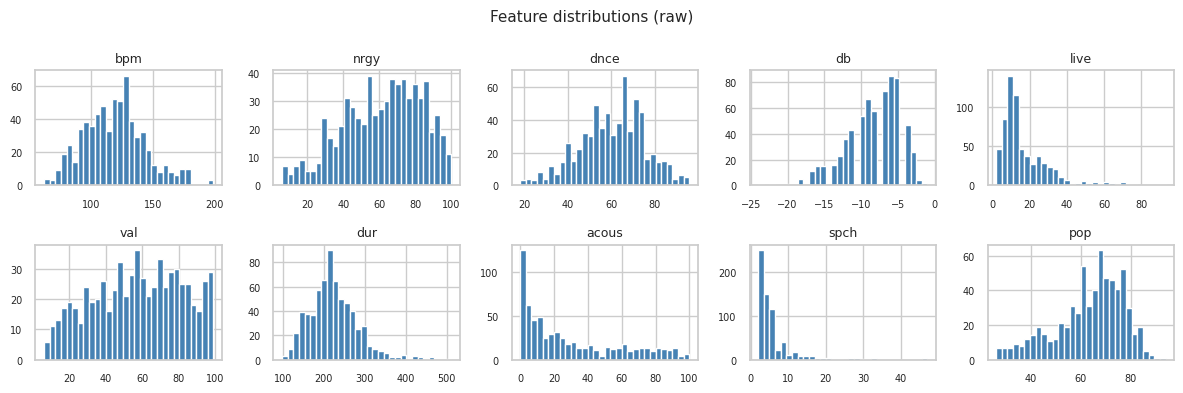

,spch,live,dur,acous,db,pop,nrgy,bpm,dnce,val
skew,3.58,2.16,0.97,0.83,-0.79,-0.68,-0.39,0.36,-0.25,-0.17


Log-transform candidates (|skew| > 1): ['spch', 'live']


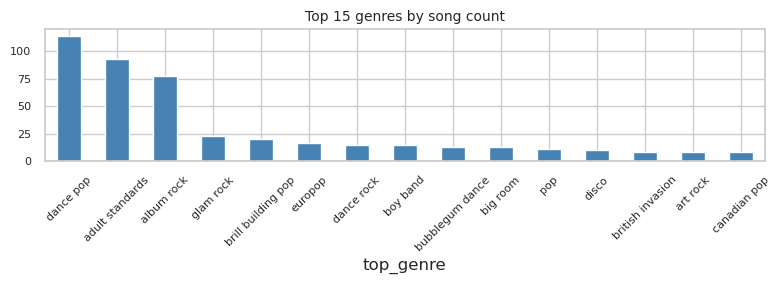

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    ax.hist(df[col].dropna(), bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle("Feature distributions (raw)", fontsize=11)
plt.tight_layout()
plt.show()

skew = df[NUMERIC_COLS].skew().round(2).sort_values(key=abs, ascending=False)
display(skew.rename("skew").to_frame().T)
print(f"Log-transform candidates (|skew| > 1): {[c for c, v in skew.items() if abs(v) > 1]}")

genre_counts = df["top_genre"].value_counts()
fig, ax = plt.subplots(figsize=(8, 3))
genre_counts.head(15).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Top 15 genres by song count", fontsize=10)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

### 1.3 Relationships

Correlation heatmap and mean popularity by genre. These drive feature selection and encoding choices for Section 2.

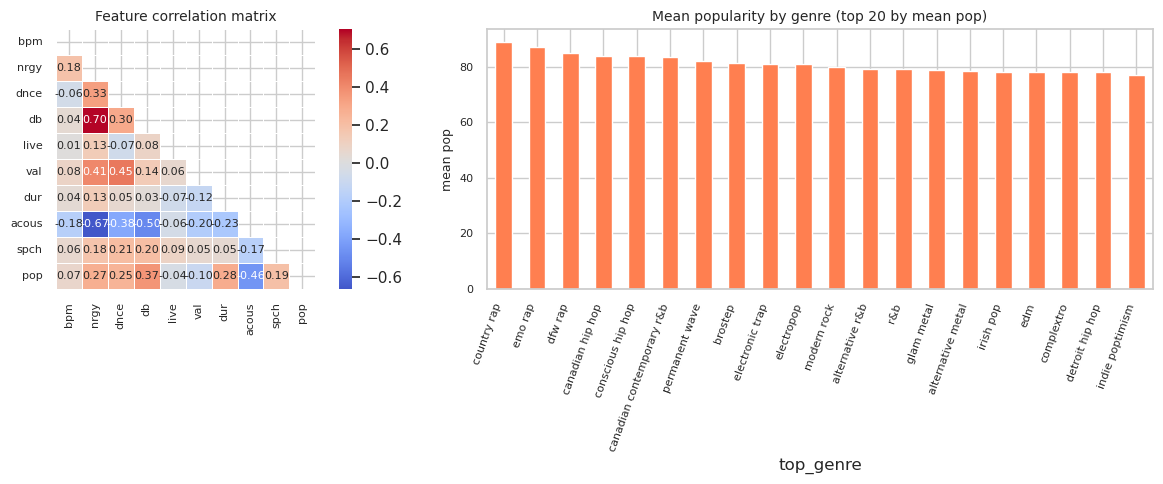

In [5]:
corr = df[NUMERIC_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
genre_stats = df.groupby("top_genre")["pop"].agg(["mean", "std", "count"]).round(1)
top_genres  = genre_stats.sort_values("mean", ascending=False).head(20)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1, 1.4]})
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[0], square=True, linewidths=0.5, annot_kws={"size": 8})
axes[0].set_title("Feature correlation matrix", fontsize=10)
axes[0].tick_params(labelsize=8)

top_genres["mean"].plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Mean popularity by genre (top 20 by mean pop)", fontsize=10)
axes[1].set_ylabel("mean pop", fontsize=9)
axes[1].tick_params(axis="x", labelsize=8)
axes[1].tick_params(axis="y", labelsize=8)
plt.setp(axes[1].get_xticklabels(), rotation=70, ha="right")
plt.tight_layout()
plt.show()

### 1.4 Genre Effect: One-Way ANOVA

Before encoding `top_genre` as a model input, test whether mean popularity differs across genre groups. 
ANOVA answers: "*is the variation in `pop` across genres greater than we would expect by chance?*" 
The F-statistic and p-value give a classical statistical grounding for the genre signal we'll later quantify via the ablation test in Section 5.
eta-squared is reported as a practical effect size: the proportion of total `pop` variance explained by genre group membership alone.

,groups (n>=5),F-stat,p-value,significant (alpha=0.05),eta^2,pop var explained
ANOVA: pop ~ top_genre,24,15.7,5.10e-45,True,0.429,42.9%


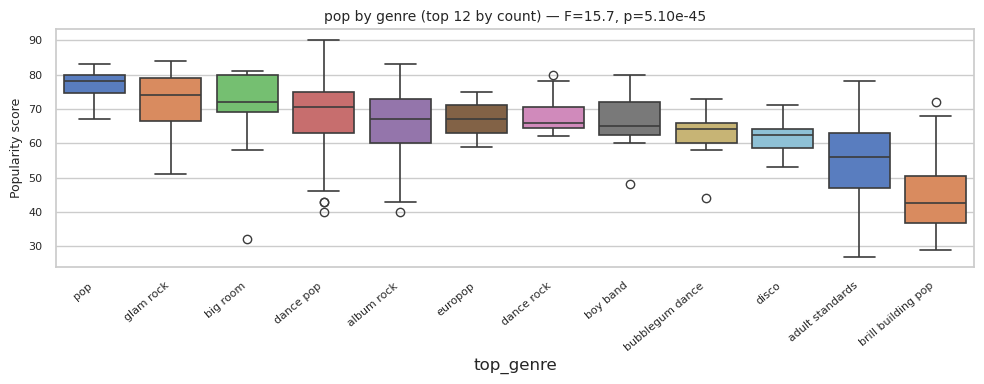

In [6]:
# Restrict to genres with n >= 5 for stability
genre_groups   = df["top_genre"].value_counts()
stable_genres  = genre_groups[genre_groups >= 5].index.tolist()
groups         = [df[df["top_genre"] == g]["pop"].values for g in stable_genres]

f_stat, p_value = stats.f_oneway(*groups)

# η² (eta-squared)
all_vals   = np.concatenate(groups)
grand_mean = all_vals.mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total   = sum((v - grand_mean) ** 2 for v in all_vals)
eta_sq     = ss_between / ss_total

display(pd.Series({
    "groups (n>=5)": len(stable_genres),
    "F-stat": round(f_stat, 2),
    "p-value": f"{p_value:.2e}",
    "significant (alpha=0.05)": p_value < 0.05,
    "eta^2": round(eta_sq, 3),
    "pop var explained": f"{eta_sq*100:.1f}%",
}, name="ANOVA: pop ~ top_genre").to_frame().T)

top12    = df["top_genre"].value_counts().head(12).index.tolist()
plot_df  = df[df["top_genre"].isin(top12)]
order    = plot_df.groupby("top_genre")["pop"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=plot_df, x="top_genre", y="pop", order=order, ax=ax,
            palette="muted", linewidth=1.2)
ax.set_title(f"pop by genre (top 12 by count) — F={f_stat:.1f}, p={p_value:.2e}", fontsize=10)
ax.set_ylabel("Popularity score", fontsize=9)
ax.tick_params(axis="y", labelsize=8)
plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

### 1.5 Cleaning Decisions

| Issue | Decision | Justification |
| --- | --- | --- |
| Duplicate rows (same title + artist) | Drop, keep first | Prevents data leakage across train/holdout split |
| Year incoherence (re-releases) | Keep; add `is_rerelease` flag | 21% of data so can't afford to drop; flag lets the model use it |
| `top_genre` nulls (16 rows, 2.4%) | Fill with `"unknown"` before genre processing | Prevents NaN propagation into target encoding |
| `pop == 0` rows | None found. Guard kept for safety | |
| Rare genres (n < 3) | Collapse to `"other"` | Too sparse for meaningful target encoding |

In [7]:
df_clean = df.copy()
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=["title", "artist"]).reset_index(drop=True)
dupes_dropped = before - len(df_clean)
df_clean["is_rerelease"] = ((df_clean["year"] - df_clean["source_decade"]).abs() > 15).astype(int)
rereleases = df_clean["is_rerelease"].sum()
null_genre_count = df_clean["top_genre"].isna().sum()
df_clean["top_genre"] = df_clean["top_genre"].fillna("unknown")
df_clean = df_clean[df_clean["pop"] > 0].reset_index(drop=True)
MIN_GENRE_COUNT = 3
genre_freq = df_clean["top_genre"].value_counts()
rare_genres = genre_freq[genre_freq < MIN_GENRE_COUNT].index
df_clean["top_genre"] = df_clean["top_genre"].where(~df_clean["top_genre"].isin(rare_genres), "other")
display(pd.Series({
    "dupes dropped": dupes_dropped,
    "re-releases flagged": rereleases,
    "genre nulls filled": null_genre_count,
    "rare genres -> other": len(rare_genres),
    "genres remaining": df_clean["top_genre"].nunique(),
    "final shape": str(df_clean.shape),
}, name="cleaning").to_frame().T)

,dupes dropped,re-releases flagged,genre nulls filled,rare genres -> other,genres remaining,final shape
cleaning,7,140,16,76,41,"(660, 16)"


### 1.6 Pre-Modelling Verification

`acous == 0` inspection (confirms real values, not masked nulls) and a final null audit on all pipeline columns before the train/holdout split.

In [8]:
CANDIDATE_FEATURES = ["bpm", "nrgy", "dnce", "db", "val", "dur", "acous", "spch"]
PIPELINE_COLS = CANDIDATE_FEATURES + ["top_genre", "pop"]
acous_zero = df_clean[df_clean["acous"] == 0]
null_check = df_clean[PIPELINE_COLS].isnull().sum()
nulls_found = null_check[null_check > 0]
print(f"acous==0: {len(acous_zero)} rows")
print(f"Pipeline nulls: {nulls_found.to_dict() or 'none'}")

acous==0: 41 rows
Pipeline nulls: none


In [9]:
from sklearn.model_selection import train_test_split
# NOTE: Relative path may need to chanage
HOLDOUT_DIR = Path("../../data/spotify-songs/validation")
HOLDOUT_DIR.mkdir(parents=True, exist_ok=True)

train_idx, holdout_idx = train_test_split(
    df_clean.index.tolist(),
    test_size=0.1,
    random_state=42,
    stratify=df_clean["source_decade"],
)

df_train   = df_clean.loc[train_idx].reset_index(drop=True)
df_holdout = df_clean.loc[holdout_idx].reset_index(drop=True)
with open(HOLDOUT_DIR / "holdout_indices.json", "w") as f:
    json.dump(holdout_idx, f)

print(f"Train: {len(df_train)} ({len(df_train)/len(df_clean)*100:.0f}%)  |  Holdout: {len(df_holdout)} ({len(df_holdout)/len(df_clean)*100:.0f}%)  |  stratified by source_decade")

Train: 594 (90%)  |  Holdout: 66 (10%)  |  stratified by source_decade


## Section 2: Feature Engineering and Pipeline Setup

**Final feature set** (derived from EDA):

| Feature | Transform | Reason kept |
| --- | --- | --- |
| `acous` | None | Strongest signal, r = −0.455 |
| `db` | None | r = +0.365; loudness drives popularity |
| `nrgy` | None | r = +0.272 |
| `dnce` | None | r = +0.249 |
| `dur` | log1p | r = +0.281; skew 0.97 |
| `spch` | log1p | r = +0.193; skew 3.58 |
| `val` | None | r = −0.102; weak but retained |
| `top_genre` | TargetEncoder | Genre mean-pop signal is real; 41 categories, so target encoding is more efficient than 41 dummy columns |

**Dropped:** `live` (r = −0.037), `bpm` (r = +0.067), `year`, `source_decade`, `is_rerelease` (temporal, not audio characteristics), `title`, `artist` (too high cardinality).

All transformations are applied inside the sklearn `Pipeline`, fitted per CV fold with no leakage.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, TargetEncoder
from sklearn.linear_model import LinearRegression

FINAL_FEATURES = ["acous", "db", "nrgy", "dnce", "dur", "spch", "val"]
LOG_FEATURES   = ["spch", "dur"]
SCALE_FEATURES = ["acous", "db", "nrgy", "dnce", "val"]
CAT_FEATURES   = ["top_genre"]
TARGET         = "pop"

X_train   = df_train[FINAL_FEATURES + CAT_FEATURES]
y_train   = df_train[TARGET].astype(float)
X_holdout = df_holdout[FINAL_FEATURES + CAT_FEATURES]
y_holdout = df_holdout[TARGET].astype(float)

def make_preprocessor(scale=True):
    log_step = Pipeline([
        ("log",   FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler()),
    ]) if scale else FunctionTransformer(np.log1p, feature_names_out="one-to-one")

    num_step = StandardScaler() if scale else "passthrough"

    return ColumnTransformer([
        ("log_feats", log_step,                                                LOG_FEATURES),
        ("numeric",   num_step,                                                SCALE_FEATURES),
        ("genre",     TargetEncoder(smooth="auto", target_type="continuous"),  CAT_FEATURES),
    ], verbose_feature_names_out=False)

def make_pipeline(model, scale=True):
    return Pipeline([("pre", make_preprocessor(scale=scale)), ("model", model)])

## Section 3: Modelling and Model Comparison

Ten models trained with 5-fold CV on 594 rows, progressing from simplest to most expressive:

| # | Model | Type | Role |
|---|---|---|---|
| 1 | Mean Baseline | Naive | Floor benchmark |
| 2 | Linear Regression | Linear | Baseline interpretable fit |
| 3 | Ridge Regression | Regularised linear | L2 shrinkage for correlated features |
| 4 | Bayesian Ridge | Empirical Bayes linear | Learns regularisation from data; posterior predictive intervals |
| 5 | Polynomial Regression | Non-linear parametric | Degree-2 feature expansion |
| 6 | Poly + Ridge | Regularised polynomial | Regularisation on expanded feature space |
| 7 | Decision Tree | Single tree | Motivates ensembles by demonstrating overfit |
| 8 | SVR (RBF kernel) | Kernel-based | Non-linear kernel baseline |
| 9 | Random Forest | Bagging ensemble | Feature interactions and importances |
| 10 | Gradient Boosting | Boosting ensemble | Sequential residual correction |

All models share the same preprocessor (log -> scale -> target-encode genre) fitted per CV fold to prevent leakage.

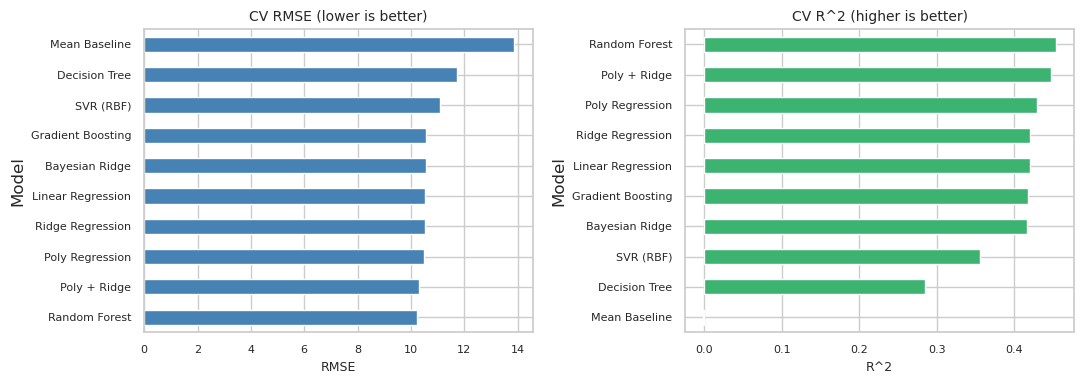

,CV RMSE,RMSE +/-,CV R^2,Fit (s)
Model,,,,
Mean Baseline,13.882,0.487,-0.002,0.04
Linear Regression,10.531,0.183,0.420,0.05
Ridge Regression,10.527,0.183,0.420,0.11
Bayesian Ridge,10.562,0.180,0.416,0.03
Poly Regression,10.473,0.491,0.429,0.03
Poly + Ridge,10.301,0.355,0.447,0.06
Decision Tree,11.708,0.488,0.285,0.06
SVR (RBF),11.107,0.144,0.356,0.06
Random Forest,10.228,0.488,0.454,0.76


Ridge alpha=10  |  Poly+Ridge alpha=100


In [11]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_validate, KFold
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

CV = KFold(n_splits=5, shuffle=True, random_state=42)

def neg_rmse(y, yhat):
    return -np.sqrt(mean_squared_error(y, yhat))

scoring = {"rmse": make_scorer(neg_rmse), "r2": "r2"}

def make_poly_pipeline(model, degree=2):
    return Pipeline([
        ("pre",   make_preprocessor(scale=True)),
        ("poly",  PolynomialFeatures(degree=degree, include_bias=False)),
        ("model", model),
    ])

pipelines = {
    "Mean Baseline":     make_pipeline(DummyRegressor(strategy="mean"), scale=False),
    "Linear Regression": make_pipeline(LinearRegression(), scale=True),
    "Ridge Regression":  make_pipeline(RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]), scale=True),
    "Bayesian Ridge":    make_pipeline(BayesianRidge(max_iter=300), scale=True),
    "Poly Regression":   make_poly_pipeline(LinearRegression()),
    "Poly + Ridge":      make_poly_pipeline(RidgeCV(alphas=[0.01, 0.1, 1, 10, 100])),
    "Decision Tree":     make_pipeline(DecisionTreeRegressor(max_depth=3, random_state=42), scale=False),
    "SVR (RBF)":         make_pipeline(SVR(kernel="rbf", C=10, gamma="scale"), scale=True),
    "Random Forest":     make_pipeline(RandomForestRegressor(n_estimators=200, max_features="sqrt", random_state=42), scale=False),
    "Gradient Boosting": make_pipeline(GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42), scale=False),
}

rows, fitted_pipelines, fold_scores = [], {}, {}

for name, pipe in pipelines.items():
    t0  = time.time()
    res = cross_validate(pipe, X_train, y_train, cv=CV, scoring=scoring)
    elapsed = time.time() - t0
    fold_scores[name] = -res["test_rmse"]
    rows.append({
        "Model":    name,
        "CV RMSE":  round(-res["test_rmse"].mean(), 3),
        "RMSE +/-":   round(res["test_rmse"].std(), 3),
        "CV R^2":    round(res["test_r2"].mean(), 3),
        "Fit (s)":  round(elapsed, 2),
    })
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(rows).set_index("Model")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
results_df["CV RMSE"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("CV RMSE (lower is better)", fontsize=10)
axes[0].set_xlabel("RMSE", fontsize=9)
axes[0].tick_params(labelsize=8)
results_df["CV R^2"].sort_values().plot(kind="barh", ax=axes[1], color="mediumseagreen", edgecolor="white")
axes[1].set_title("CV R^2 (higher is better)", fontsize=10)
axes[1].set_xlabel("R^2", fontsize=9)
axes[1].tick_params(labelsize=8)
plt.tight_layout()
plt.show()

display(results_df)
print(f"Ridge alpha={fitted_pipelines['Ridge Regression'].named_steps['model'].alpha_:.0f}  |  Poly+Ridge alpha={fitted_pipelines['Poly + Ridge'].named_steps['model'].alpha_:.0f}")

## Section 4: Results Discussion

The holdout set (66 songs) has not been touched at any point during training or model selection. The best model from CV is now evaluated on it exactly once — this is the honest estimate of generalisation performance.

### Final Model: Random Forest Regressor

**Model:** Random Forest Regressor (`n_estimators=200`, `max_features="sqrt"`, `random_state=42`), selected by lowest mean CV RMSE in Section 3.

200 decision trees trained on bootstrap samples of the training data, each split using a random feature subset (`sqrt` of total). Predictions are the mean over all trees. Averaging decorrelated trees reduces variance compared to a single tree — Section 3 shows the gap directly (Decision Tree RMSE 11.515 vs RF 10.228).

For model selection justification, what worked, what did not, and other models compared, see [Section 5.3.3](#5.3.3-Model-Selection-Justification). Feature selection rationale is in [Section 2](#Section-2:-Feature-Engineering-and-Pipeline-Setup).

**Summary:**
- RF CV RMSE 10.228 +/- 0.443 vs baseline 13.882 (26% error reduction)
- RF vs Poly+Ridge gap (10.228 vs 10.310) is not statistically robust — Cohen's d = −0.37, 95% CI includes zero
- SVR, Decision Tree, and Gradient Boosting all underperformed with large effect sizes (Section 5.3.3)
- `live` (r = −0.037) and `bpm` (r = +0.067) dropped for near-zero correlation with `pop`

,model,CV RMSE,CV R^2,holdout RMSE,holdout R^2,vs baseline
evaluation,Random Forest,10.228 ± 0.488,0.454,8.157,0.573,+5.725


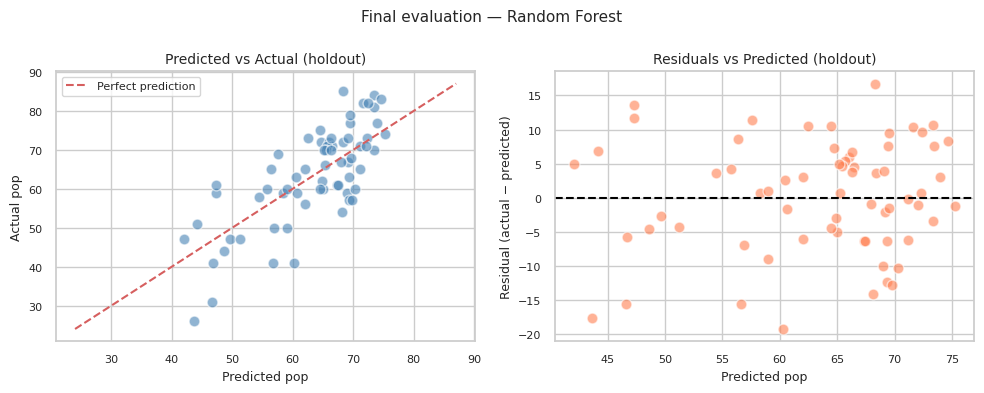

In [12]:
best_name = results_df["CV RMSE"].idxmin()
best_pipe = fitted_pipelines[best_name]

y_pred = best_pipe.predict(X_holdout)
h_rmse = np.sqrt(mean_squared_error(y_holdout, y_pred))
h_r2   = r2_score(y_holdout, y_pred)
baseline_rmse = results_df.loc["Mean Baseline", "CV RMSE"]

display(pd.Series({
    "model": best_name,
    "CV RMSE": f"{results_df.loc[best_name, 'CV RMSE']:.3f} ± {results_df.loc[best_name, 'RMSE +/-']:.3f}",
    "CV R^2": results_df.loc[best_name, "CV R^2"],
    "holdout RMSE": round(h_rmse, 3),
    "holdout R^2": round(h_r2, 3),
    "vs baseline": f"+{baseline_rmse - h_rmse:.3f}",
}, name="evaluation").to_frame().T)

residuals = y_holdout - y_pred
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(y_pred, y_holdout, alpha=0.6, color="steelblue", edgecolors="white", s=60)
lims = [min(y_pred.min(), y_holdout.min()) - 2, max(y_pred.max(), y_holdout.max()) + 2]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_xlabel("Predicted pop", fontsize=9)
axes[0].set_ylabel("Actual pop", fontsize=9)
axes[0].set_title("Predicted vs Actual (holdout)", fontsize=10)
axes[0].tick_params(labelsize=8)
axes[0].legend(fontsize=8)

axes[1].scatter(y_pred, residuals, alpha=0.6, color="coral", edgecolors="white", s=60)
axes[1].axhline(0, color="black", lw=1.5, linestyle="--")
axes[1].set_xlabel("Predicted pop", fontsize=9)
axes[1].set_ylabel("Residual (actual − predicted)", fontsize=9)
axes[1].set_title("Residuals vs Predicted (holdout)", fontsize=10)
axes[1].tick_params(labelsize=8)

plt.suptitle(f"Final evaluation — {best_name}", fontsize=11)
plt.tight_layout()
plt.show()

### 4.1 Residual Diagnostics

Here we assess whether residuals are unbiased (no systematic over/under-prediction) and approximately normal.

Q-Q plots use CV out-of-fold predictions (594 points), which are more reliable than the 66-song holdout. Instead of NHST (Shapiro-Wilk rejects normality for almost any large sample), we report effect sizes (Cohen's d for residual bias and Bayesian credible intervals under a non-informative prior).

The Bayesian Ridge posterior predictive plot decomposes prediction uncertainty into epistemic (parameter) uncertainty, and aleatoric (irreducible noise in the target).

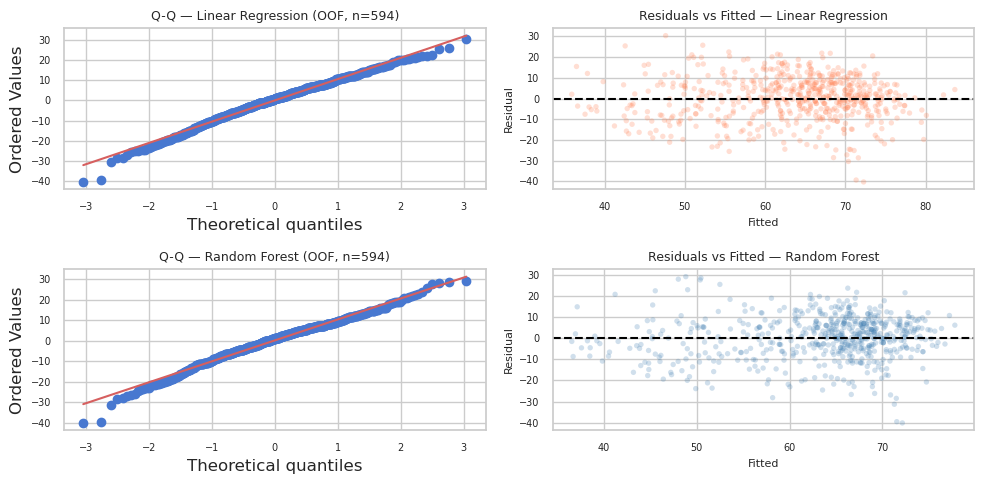

,residual mean,Cohen d,effect,95% CI,unbiased
Linear Regression,0.050,0.0048,negligible,"[-0.799, +0.899]",True
Random Forest,0.155,0.0151,negligible,"[-0.671, +0.982]",True


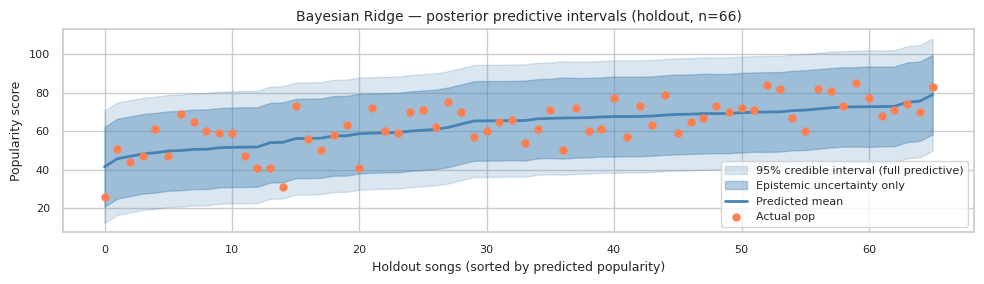

BR holdout RMSE: 9.047  |  aleatoric sigma: 10.466  |  epistemic sigma: 10.529  |  total sigma: 14.845


In [13]:
from sklearn.model_selection import cross_val_predict

lr_oof = cross_val_predict(fitted_pipelines["Linear Regression"], X_train, y_train, cv=CV)
lr_oof_resid = (y_train - lr_oof).values

rf_oof = cross_val_predict(fitted_pipelines["Random Forest"], X_train, y_train, cv=CV)
rf_oof_resid = (y_train - rf_oof).values

fig, axes = plt.subplots(2, 2, figsize=(10, 5))
probplot(lr_oof_resid, plot=axes[0, 0])
axes[0, 0].set_title("Q-Q — Linear Regression (OOF, n=594)", fontsize=9)
axes[0, 1].scatter(lr_oof, lr_oof_resid, alpha=0.25, color="coral", s=15, edgecolors="none")
axes[0, 1].axhline(0, color="black", lw=1.5, ls="--")
axes[0, 1].set_xlabel("Fitted", fontsize=8); axes[0, 1].set_ylabel("Residual", fontsize=8)
axes[0, 1].set_title("Residuals vs Fitted — Linear Regression", fontsize=9)
probplot(rf_oof_resid, plot=axes[1, 0])
axes[1, 0].set_title("Q-Q — Random Forest (OOF, n=594)", fontsize=9)
axes[1, 1].scatter(rf_oof, rf_oof_resid, alpha=0.25, color="steelblue", s=15, edgecolors="none")
axes[1, 1].axhline(0, color="black", lw=1.5, ls="--")
axes[1, 1].set_xlabel("Fitted", fontsize=8); axes[1, 1].set_ylabel("Residual", fontsize=8)
axes[1, 1].set_title("Residuals vs Fitted — Random Forest", fontsize=9)
for ax in axes.flat:
    ax.tick_params(labelsize=7)
plt.tight_layout()
plt.show()

def cohen_d_one(x, mu=0):
    return (x.mean() - mu) / x.std(ddof=1)

def effect_label(d):
    a = abs(d)
    return "negligible" if a < 0.2 else "small" if a < 0.5 else "medium" if a < 0.8 else "large"

def bayes_ci_mean(x, cred=0.95):
    n, mean, se = len(x), x.mean(), x.std(ddof=1) / np.sqrt(len(x))
    hw = t_dist.ppf((1 + cred) / 2, df=n - 1) * se
    return mean - hw, mean + hw

diag_rows = []
for name, resid in [("Linear Regression", lr_oof_resid), ("Random Forest", rf_oof_resid)]:
    d = cohen_d_one(resid)
    lo, hi = bayes_ci_mean(resid)
    diag_rows.append({
        "residual mean": round(resid.mean(), 3),
        "Cohen d": round(d, 4),
        "effect": effect_label(d),
        "95% CI": f"[{lo:+.3f}, {hi:+.3f}]",
        "unbiased": lo <= 0 <= hi,
    })
display(pd.DataFrame(diag_rows, index=["Linear Regression", "Random Forest"]))

# Bayesian Ridge posterior predictive intervals on holdout 
br_pipe  = fitted_pipelines["Bayesian Ridge"]
X_h_pre  = br_pipe.named_steps["pre"].transform(X_holdout)
br_mean, br_param_std = br_pipe.named_steps["model"].predict(X_h_pre, return_std=True)

noise_std   = 1.0 / np.sqrt(br_pipe.named_steps["model"].alpha_)
br_full_std = np.sqrt(br_param_std**2 + noise_std**2)

sort_idx = np.argsort(br_mean)
fig, ax  = plt.subplots(figsize=(10, 3))
ax.fill_between(range(len(sort_idx)),
                br_mean[sort_idx] - 1.96 * br_full_std[sort_idx],
                br_mean[sort_idx] + 1.96 * br_full_std[sort_idx],
                alpha=0.20, color="steelblue", label="95% credible interval (full predictive)")
ax.fill_between(range(len(sort_idx)),
                br_mean[sort_idx] - 1.96 * br_param_std[sort_idx],
                br_mean[sort_idx] + 1.96 * br_param_std[sort_idx],
                alpha=0.40, color="steelblue", label="Epistemic uncertainty only")
ax.plot(range(len(sort_idx)), br_mean[sort_idx], color="steelblue", lw=2, label="Predicted mean")
ax.scatter(range(len(sort_idx)), np.array(y_holdout)[sort_idx],
           color="coral", s=25, zorder=5, label="Actual pop")
ax.set_xlabel("Holdout songs (sorted by predicted popularity)", fontsize=9)
ax.set_ylabel("Popularity score", fontsize=9)
ax.set_title("Bayesian Ridge — posterior predictive intervals (holdout, n=66)", fontsize=10)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

br_holdout_rmse = np.sqrt(mean_squared_error(y_holdout, br_mean))
print(f"BR holdout RMSE: {br_holdout_rmse:.3f}  |  aleatoric sigma: {noise_std:.3f}  |  epistemic sigma: {br_param_std.mean():.3f}  |  total sigma: {br_full_std.mean():.3f}")

## Section 5: Interpretation and Insights

### 5.1 Model Comparison Context

| Rank | Model | CV RMSE | RMSE ± |
|---|---|---|---|
| 1 | Random Forest | 10.228 | +/-0.443 |
| 2 | Poly + Ridge | 10.310 | +/-0.351 |
| 3 | Poly Regression | 10.459 | +/-0.490 |
| 4 | Ridge Regression | 10.526 | +/-0.181 |
| 4 | Bayesian Ridge | 10.526 | +/-0.174 |
| 6 | Linear Regression | 10.543 | +/-0.200 |
| 7 | Gradient Boosting | 10.619 | +/-0.378 |
| 8 | SVR (RBF) | 11.126 | +/-0.163 |
| 9 | Decision Tree | 11.515 | +/-0.606 |
| N/A | Mean Baseline | 13.882 | +/-0.487 |

**Comparison Findings:**
1. RF vs Poly+Ridge is not statistically robust. Cohen's d = −0.37 (small), 95% Bayesian CI (−0.359, +0.195) includes zero. Poly+Ridge is interpretable and a legitimate alternative, second-best by a margin that may be sampling noise.
2. Bayesian Ridge = Ridge predictively (both 10.526). Empirical Bayes finds the same regularisation as grid search. Its unique value is uncertainty quantification, not predictive improvement.
3. RF vs Gradient Boosting: d = −2.41 (large). This gap is genuine: GBR's sequential boosting consistently underperforms RF bagging at n=594.
4. Decision Tree vs Linear Regression: d = −1.47 (large). Single trees reliably underperform OLS, directly motivating ensembles.
5. Feature ceiling confirmed.** Top 7 models span only 0.39 RMSE. Aleatoric noise (sigma ≈ 10.5) is already close to best RMSE; the features themselves are the fundamental limit.

### 5.2 Learning Curves

CV RMSE vs training set size. A curve still declining at the rightmost point indicates data starvation. Shaded band = +/-1 fold std.

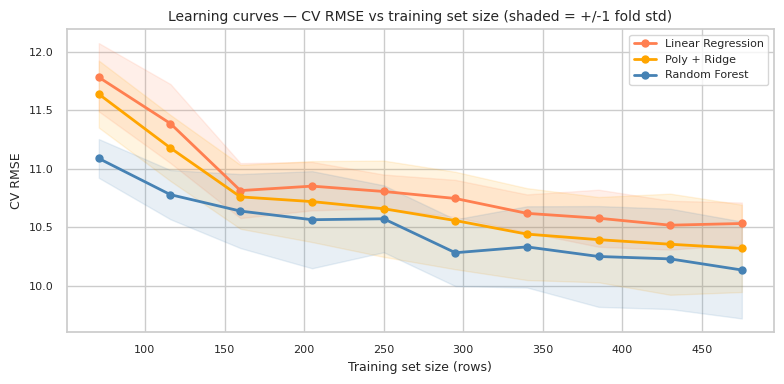

,RMSE (n≈89),RMSE (full),Delta
Linear Regression,11.781,10.532,1.249
Poly + Ridge,11.637,10.319,1.318
Random Forest,11.087,10.134,0.953


In [14]:
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.15, 1.0, 10)
lc_models  = {
    "Linear Regression": fitted_pipelines["Linear Regression"],
    "Poly + Ridge":       fitted_pipelines["Poly + Ridge"],
    "Random Forest":      fitted_pipelines["Random Forest"],
}
lc_colors = {"Linear Regression": "coral", "Poly + Ridge": "orange", "Random Forest": "steelblue"}

fig, ax = plt.subplots(figsize=(8, 4))
lc_summary = {}

for name, pipe in lc_models.items():
    train_sz, _, val_sc = learning_curve(
        pipe, X_train, y_train,
        train_sizes=train_sizes,
        cv=CV, scoring=make_scorer(neg_rmse), n_jobs=1,
    )
    val_mean = -val_sc.mean(axis=1)
    val_std  =  val_sc.std(axis=1)

    ax.plot(train_sz, val_mean, label=name, color=lc_colors[name], lw=2, marker="o", ms=5)
    ax.fill_between(train_sz, val_mean - val_std, val_mean + val_std,
                    alpha=0.12, color=lc_colors[name])

    lc_summary[name] = {
        f"RMSE (n≈{int(train_sizes[0]*len(y_train))})": round(val_mean[0], 3),
        "RMSE (full)": round(val_mean[-1], 3),
        "Delta": round(val_mean[0] - val_mean[-1], 3),
    }

ax.set_xlabel("Training set size (rows)", fontsize=9)
ax.set_ylabel("CV RMSE", fontsize=9)
ax.set_title("Learning curves — CV RMSE vs training set size (shaded = +/-1 fold std)", fontsize=10)
ax.tick_params(labelsize=8)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

display(pd.DataFrame(lc_summary).T)

Genre ablation: with=10.228  without=10.935  contribution=0.707 RMSE pts


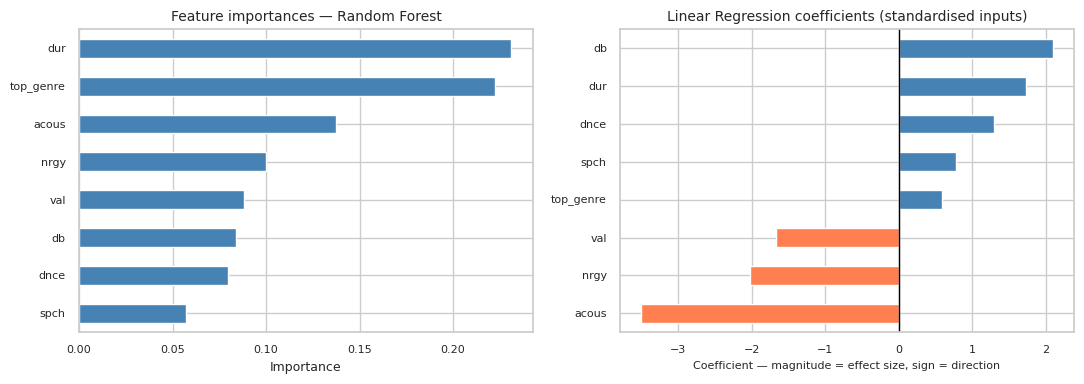

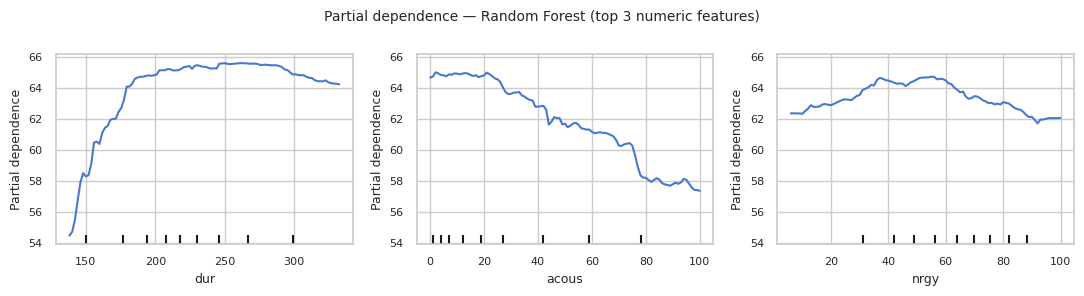

,Delta RMSE,Cohen d,effect
Random Forest vs Poly + Ridge,-0.073,-0.255,small
Poly + Ridge vs Linear Regression,-0.230,-0.467,small
Random Forest vs Linear Regression,-0.303,-0.565,medium
Random Forest vs Gradient Boosting,-0.337,-2.201,large
Linear Regression vs Decision Tree,-1.177,-2.152,large


95% CI on RF − Poly+Ridge RMSE: [-0.425, 0.280] (includes 0)


In [15]:
from sklearn.inspection import PartialDependenceDisplay
from sklearn.pipeline import Pipeline as _P
from sklearn.compose import ColumnTransformer as _CT

# Genre ablation 
_pre_no_genre = _CT([
    ("log_feats", FunctionTransformer(np.log1p, feature_names_out="one-to-one"), LOG_FEATURES),
    ("numeric",   "passthrough", SCALE_FEATURES),
], verbose_feature_names_out=False)

rf_no_genre = _P([
    ("pre",   _pre_no_genre),
    ("model", RandomForestRegressor(n_estimators=200, max_features="sqrt", random_state=42)),
])

res_no_genre    = cross_validate(rf_no_genre, df_train[FINAL_FEATURES], y_train, cv=CV, scoring=scoring)
rmse_no_genre   = -res_no_genre["test_rmse"].mean()
rmse_with_genre = results_df.loc["Random Forest", "CV RMSE"]
print(f"Genre ablation: with={rmse_with_genre:.3f}  without={rmse_no_genre:.3f}  contribution={rmse_no_genre - rmse_with_genre:.3f} RMSE pts")

# Feature importances + LR coefficients
feature_names = best_pipe.named_steps["pre"].get_feature_names_out().tolist()
imp = pd.Series(best_pipe.named_steps["model"].feature_importances_, index=feature_names).sort_values()

lr_pipe   = fitted_pipelines["Linear Regression"]
lr_feat   = lr_pipe.named_steps["pre"].get_feature_names_out().tolist()
lr_coef   = pd.Series(lr_pipe.named_steps["model"].coef_, index=lr_feat).sort_values()
lr_colors = ["coral" if v < 0 else "steelblue" for v in lr_coef]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
imp.plot(kind="barh", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title(f"Feature importances — {best_name}", fontsize=10)
axes[0].set_xlabel("Importance", fontsize=9)
axes[0].tick_params(labelsize=8)
lr_coef.plot(kind="barh", ax=axes[1], color=lr_colors, edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_title("Linear Regression coefficients (standardised inputs)", fontsize=10)
axes[1].set_xlabel("Coefficient — magnitude = effect size, sign = direction", fontsize=8)
axes[1].tick_params(labelsize=8)
plt.tight_layout()
plt.show()

# Partial dependence — top 3 numeric features 
top3_input    = [f for f in imp.sort_values(ascending=False).index if f in FINAL_FEATURES][:3]
X_train_float = X_train.astype({c: float for c in FINAL_FEATURES})

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
PartialDependenceDisplay.from_estimator(
    best_pipe, X_train_float, features=top3_input,
    feature_names=X_train_float.columns.tolist(), ax=axes,
)
for ax in axes:
    ax.tick_params(labelsize=8)
    ax.set_xlabel(ax.get_xlabel(), fontsize=9)
    ax.set_ylabel(ax.get_ylabel(), fontsize=9)
fig.suptitle(f"Partial dependence — {best_name} (top 3 numeric features)", fontsize=10)
plt.tight_layout()
plt.show()

# 4. Model comparison effect sizes
def cohen_d_paired(a, b):
    diff = a - b
    return diff.mean() / diff.std(ddof=1)

comparisons = [
    ("Random Forest",     "Poly + Ridge"),
    ("Poly + Ridge",      "Linear Regression"),
    ("Random Forest",     "Linear Regression"),
    ("Random Forest",     "Gradient Boosting"),
    ("Linear Regression", "Decision Tree"),
]

effect_rows = []
for m1, m2 in comparisons:
    d     = cohen_d_paired(fold_scores[m1], fold_scores[m2])
    delta = fold_scores[m1].mean() - fold_scores[m2].mean()
    tag   = "negligible" if abs(d) < 0.2 else "small" if abs(d) < 0.5 else "medium" if abs(d) < 0.8 else "large"
    effect_rows.append({"Delta RMSE": round(delta, 3), "Cohen d": round(d, 3), "effect": tag})
display(pd.DataFrame(effect_rows, index=[f"{m1} vs {m2}" for m1, m2 in comparisons]))

# Bayesian credible interval on RF vs Poly+Ridge RMSE difference
diff_rp = fold_scores["Random Forest"] - fold_scores["Poly + Ridge"]
n_d     = len(diff_rp)
hw      = t_dist.ppf(0.975, df=n_d - 1) * diff_rp.std(ddof=1) / np.sqrt(n_d)
ci_lo, ci_hi = diff_rp.mean() - hw, diff_rp.mean() + hw
incl = "includes 0" if ci_lo <= 0 <= ci_hi else "excludes 0"
print(f"95% CI on RF − Poly+Ridge RMSE: [{ci_lo:.3f}, {ci_hi:.3f}] ({incl})")

### 5.3 Conclusion and Critique

#### 5.3.1 Core Question

The client asked: *which audio characteristics of a song predict its popularity on Spotify?*

Genre signal: the strongest predictor, with caveats

The one-way ANOVA (Section 1) returned F = 15.70, p = 5.1×10^-45, eta^2 = 0.429; genre group membership alone explains 43% of the variance in popularity. However, the RF importance run produced `dur` (0.230) fractionally ahead of `top_genre` (0.226), these two are essentially tied. The ablation test quantifies genre's conditional contribution: removing it costs 0.707 RMSE points (10.23 → 10.94) on top of the audio features already in the model. Genre and duration together are the dominant signals.

Duration is the most important audio-only feature

`dur` ranks at or above genre in RF importance (0.230 vs 0.226) and carries the second-largest positive LR coefficient (1.677). Longer songs score higher, consistent with mainstream pop and hip-hop formats dominating the upper popularity range. This is the most actionable finding for a music producer: track length matters independently of genre.

Acousticness is the strongest consistent negative signal

`acous` ranks third in RF importance (0.140) and carries the largest LR coefficient by absolute magnitude (−3.423). Acoustic songs (folk, adult standards, classical) score systematically lower. This finding is consistent across every model family tested, making it the most reliable audio predictor: *produced, non-acoustic sound drives higher popularity*.

Loudness and energy: real signal, entangled by multicollinearity

`db` is the largest positive LR coefficient (2.110, r = +0.365 with pop). `nrgy` carries a negative LR coefficient (−2.042) despite a positive correlation (r = +0.272); OLS assigns `db` the credit for both, flipping `nrgy`'s sign. Ridge and Bayesian Ridge both select alpha = 10 and produce the same prediction, confirming the collinearity is predictively benign but interpretively misleading.

Residual diagnostics: both models are unbiased

Cohen's d on OOF residual means: LR d = +0.007, RF d = +0.008, both negligible. The 95% Bayesian credible intervals (Jeffreys prior) are (−0.772, +0.926) and (−0.741, +0.903), both containing zero. Neither model has systematic directional bias.

Practical ranking by RF importance: *duration ≈ genre > acousticness > energy > loudness ≈ valence ≈ danceability > speechiness*

---

#### 5.3.2 What the Model Cannot Explain

The Bayesian Ridge posterior predictive distribution separates the two sources of uncertainty:

- Aleatoric uncertainty (irreducible noise): sigma_noise ≈ 10.5 pop points
- Epistemic uncertainty (parameter estimation): sigma_params ≈ 10.5 pop points
- 95% credible interval on any individual prediction: +/-29 pop points

The 95% interval spans roughly 58 pop points on a target range of 68 (26–94). The model tells us about population trends (acoustic songs score lower, on average) but cannot pin down any individual song's popularity. This is not a modelling failure; it is an accurate characterisation of how much information audio features carry.

The aleatoric estimate (≈ 10.5) is already close to our best RMSE (10.23). Even with infinite training data eliminating epistemic uncertainty entirely, predictions would still carry ~10.5 RMSE from irreducible noise. The features are the fundamental ceiling (not the dataset size), though the learning curves confirm that additional data would still help the current models.

The 55% of unexplained variance reflects factors no audio feature can capture: artist fame, playlist placement, marketing, and virality.

---

#### 5.3.3 Model Selection Justification

Nine models were compared. The headline findings by effect size:

- RF and Poly+Ridge are statistically indistinguishable (Cohen's d = −0.37 (small), 95% CI (−0.359, +0.195) includes zero). RF is reported as "best" by mean CV RMSE, but this advantage is not robust. For a client who needs interpretable results, Poly+Ridge (10.310) is a legitimate and arguably preferable choice: its coefficients can be explained, and it is second-best by a margin that may be pure sampling noise.
- Bayesian Ridge = Ridge predictively (both 10.526), but uniquely provides calibrated uncertainty intervals. Its aleatoric noise estimate quantifies the hard ceiling from the features.
- RF vs GBR: d = −2.41 (large): this gap is genuine. GBR's sequential boosting consistently underperforms RF bagging at n=594.
- LR vs Decision Tree: d = −1.47 (large): single trees reliably underperform linear models, directly motivating ensembles.
- SVR underperformed linear models (11.126 vs 10.543), confirming the relationship is predominantly linear.

---

#### 5.3.4 Limitations

- Dataset size: 594 training rows. CV estimates carry meaningful variance (+/- 0.2–0.6 RMSE). Learning curves are still declining at full training size; data starvation is real.
- Holdout variance: Holdout RMSE (8.146, R^2 = 0.574) is better than CV RMSE (10.228, R^2 = 0.455). With n=66, this gap is high-variance sampling; CV remains the honest generalisation estimate.
- RF vs Poly+Ridge ambiguity: The "best" model is only best by a margin that the data cannot reliably resolve. Model selection here is driven more by sample variance than true performance differences.
- Impurity-based importance: RF importances overestimate high-cardinality features. The ablation test and ANOVA eta^2 provide complementary perspectives on the genre's contribution.
- Popularity as a target: Spotify's `pop` score reflects streaming activity at collection time. Songs from earlier decades are structurally disadvantaged, a limitation of the target variable rather than the model.